# Matplotlib General Usage Guide

Matplotlib is the core library for creating graphs and charts in Python. It gives you total control over how your graphs look, from the size of the window to the color of the lines.

This guide progresses logically: starting with how a graph is built, how to use it specifically within this notebook environment, and finally exploring the different types of charts you can create.


# Part 0: Setup

In [ ]:
# installing matplotlib 
!pip install matplotlib 

# other packages we will use in this guide
!pip install numpy pandas


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 1: Graph Anatomy

Before drawing anything, you must understand the two main layers of a Matplotlib graph:
* **The Figure (`fig`):** Think of this as the physical piece of paper or the overall blank canvas.
* **The Axes (`ax`):** This is the actual chart box *drawn onto the paper*. It holds the grid, the X/Y tick marks, the labels, and the lines themselves. 

*Note: In Matplotlib, "Axes" refers to a single plot area, not just the plural of a geometric axis line.*


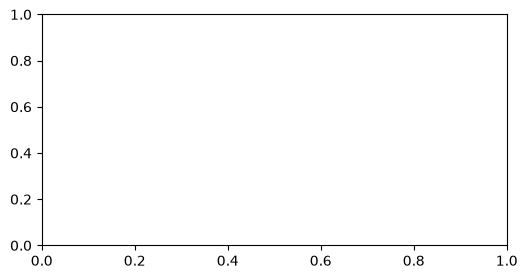

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Let's create a blank canvas (Figure) and one empty chart box (Axes)
fig, ax = plt.subplots(figsize=(6, 3))


## Part 2: Usage in Notebooks

Working with Matplotlib inside a Jupyter Notebook or Google Colab has a few specific quirks you need to know.

**1. The Magic Command**
Historically, you had to use a "magic command" (`%matplotlib inline`) to force graphs to appear inside the notebook instead of opening in a new window. Most modern notebooks do this by default now, but it's good practice to include it at the top of your files.

**2. The `plt.show()` Command**
If you plot something in a notebook cell, Jupyter will try to display it automatically. However, it will also print out ugly memory text like `<matplotlib.lines.Line2D at 0x...>` above the graph. To prevent this and render the graph cleanly, *always* end your plotting cells with `plt.show()`.


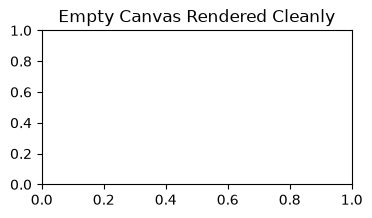

In [2]:
%matplotlib inline

# Example of a clean notebook render
fig, ax = plt.subplots(figsize=(4, 2))
ax.set_title("Empty Canvas Rendered Cleanly")

# plt.show() tells the notebook: "I'm done building the graph, display it now and hide the memory text"
plt.show()


## Part 3: Plotting on Graphs

Now that we have our canvas and understand the notebook environment, let's actually put data onto a graph. We do this by calling plotting commands directly on our `Axes` object.


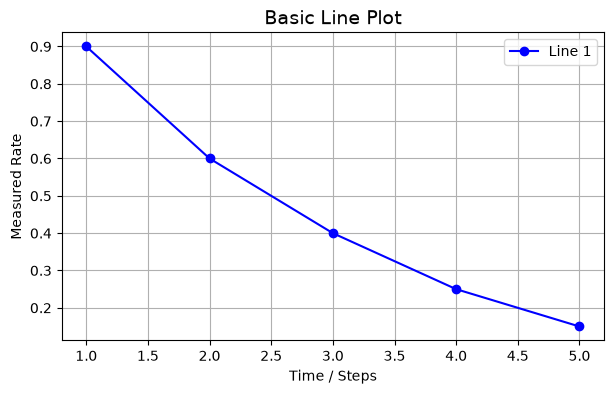

In [3]:
# 1. Create the canvas and axes
fig, ax = plt.subplots(figsize=(7, 4))

# 2. Create some simple X and Y data points
time_steps = np.arange(1, 6)
measured_values = [0.9, 0.6, 0.4, 0.25, 0.15]

# 3. Draw the data as a blue line with circle markers
ax.plot(time_steps, measured_values, color="blue", marker="o", label="Line 1")

# 4. Customize the chart with titles, labels, a grid, and a legend box
ax.set_title("Basic Line Plot", fontsize=14)
ax.set_xlabel("Time / Steps")
ax.set_ylabel("Measured Rate")
ax.grid(True)
ax.legend()

# 5. Display cleanly in the notebook
plt.show()


## Part 4: Plotting Multiple Lines

If you want to compare two different sets of data on the same graph, just call the plotting function multiple times. Matplotlib will automatically overlay the lines on top of each other.


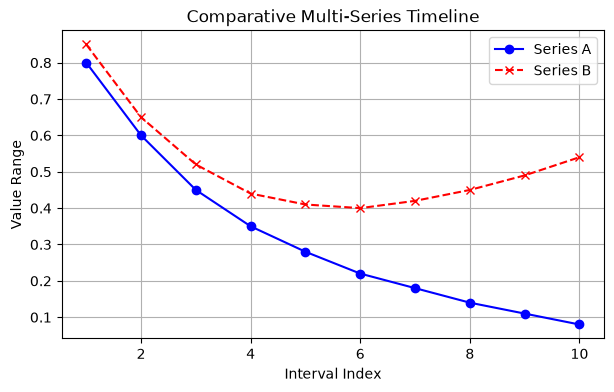

In [4]:
x_axis = np.arange(1, 11)
sequence_a = [0.8, 0.6, 0.45, 0.35, 0.28, 0.22, 0.18, 0.14, 0.11, 0.08]
sequence_b = [0.85, 0.65, 0.52, 0.44, 0.41, 0.40, 0.42, 0.45, 0.49, 0.54]

# We can also use a shortcut: plt.plot() directly plots to the most recently created Figure
plt.figure(figsize=(7, 4))

plt.plot(x_axis, sequence_a, color="blue", marker="o", linestyle="-", label="Series A")
plt.plot(x_axis, sequence_b, color="red", marker="x", linestyle="--", label="Series B")

plt.title("Comparative Multi-Series Timeline")
plt.xlabel("Interval Index")
plt.ylabel("Value Range")
plt.legend()
plt.grid(True)
plt.show()


## Part 5: Side-by-Side Plots (Subplots)

Sometimes you want to look at two entirely separate charts side-by-side instead of putting them on top of each other. We use `plt.subplots(rows, columns)` to split our canvas into a grid.

This gives us an array of axes. A 1x2 grid means `axes[0]` is the left plot, and `axes[1]` is the right plot.


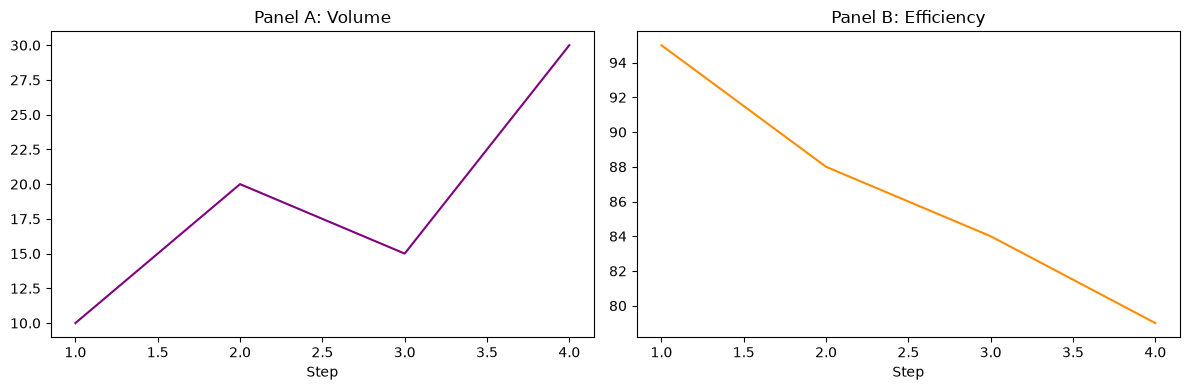

In [5]:
# Create a grid layout with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Configure the Left Chart Box
axes[0].plot([1, 2, 3, 4], [10, 20, 15, 30], color="purple")
axes[0].set_title("Panel A: Volume")
axes[0].set_xlabel("Step")

# Configure the Right Chart Box
axes[1].plot([1, 2, 3, 4], [95, 88, 84, 79], color="darkorange")
axes[1].set_title("Panel B: Efficiency")
axes[1].set_xlabel("Step")

# Automatically fixes spacing so titles don't crash into each other
plt.tight_layout()
plt.show()


## Part 6: Histograms (Data Distributions)

A histogram cuts a large list of numbers up into intervals (called bins) and counts how many numbers fall into each bar. This helps you instantly see the spread and shape of your data.


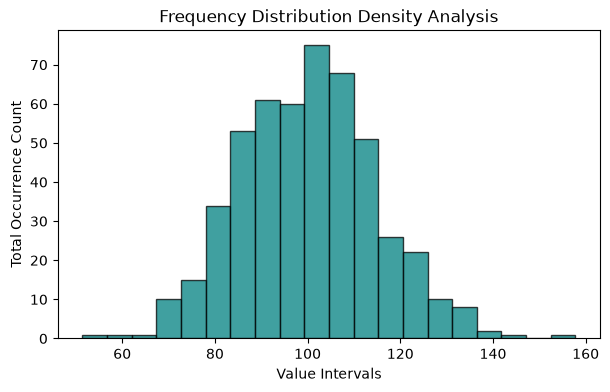

In [6]:
# Generate a list of random numbers forming a bell curve
np.random.seed(42)
distribution_data = np.random.normal(loc=100, scale=15, size=500)

plt.figure(figsize=(7, 4))
# Draw the histogram bars
plt.hist(distribution_data, bins=20, color="teal", edgecolor="black", alpha=0.75)

plt.title("Frequency Distribution Density Analysis")
plt.xlabel("Value Intervals")
plt.ylabel("Total Occurrence Count")
plt.show()


## Part 7: Heatmaps (Grid and Matrix Displays)

A heatmap turns a spreadsheet grid of numbers directly into a grid of colors. This is used to find relationships between variables, where bright or deep colors stand for high numbers.


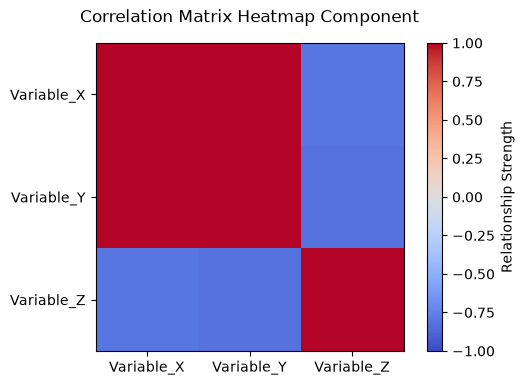

In [15]:
sample_df = pd.DataFrame({
    "Variable_X": [1, 2, 3, 4, 5],
    "Variable_Y": [1.2, 1.8, 3.1, 3.9, 4.8],
    "Variable_Z": [9, 7, 1, 4, 2]
})

correlation_matrix = sample_df.corr()

plt.figure(figsize=(6, 4))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Relationship Strength")

plt.xticks(range(len(sample_df.columns)), sample_df.columns)
plt.yticks(range(len(sample_df.columns)), sample_df.columns)
plt.title("Correlation Matrix Heatmap Component", pad=15)

plt.show()


Alternatively seaborn enablesyou to do the same you can refer to the [seaborn guide](./Seaborn.ipynb) 

## Part 8: Horizontal Bar Charts

Normal vertical bar charts look messy if your category labels have long text strings because the words get squished together. A horizontal bar chart (`barh`) solves this by letting text read naturally from left to right.


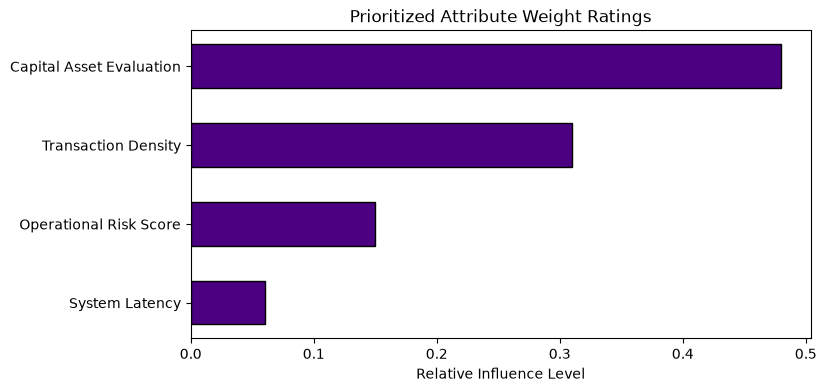

In [10]:
categories = ["Operational Risk Score", "Capital Asset Evaluation", "Transaction Density", "System Latency"]
importance_weights = [0.15, 0.48, 0.31, 0.06]

# Sort the items from smallest to largest so the chart looks clean
sorted_sequence = np.argsort(importance_weights)
categories = [categories[i] for i in sorted_sequence]
importance_weights = [importance_weights[i] for i in sorted_sequence]

plt.figure(figsize=(8, 4))
plt.barh(categories, importance_weights, color="indigo", edgecolor="black", height=0.55)

plt.title("Prioritized Attribute Weight Ratings")
plt.xlabel("Relative Influence Level")
plt.show()


## Part 9: Practice Challenge

### **The Scenario**:
You need to create a simple two-panel dashboard summarizing server performance.

### **The Requirements**:
1. Initialize a `plt.subplots(1, 2, figsize=(12, 5))` layout grid framework.
2. In the **Left Panel (`axes[0]`)**: Generate an array of data points using `np.random.exponential(scale=25, size=800)` and display it as a **Histogram** with 25 bars. Give it a title and labels.
3. In the **Right Panel (`axes[1]`)**: Draw a **Line Graph** tracking 4 steps. Plot line 1: `[80, 55, 30, 15]` labeled "Error Events", and plot line 2: `[70, 70, 70, 70]` labeled "Safety Ceiling". Add a grid and a legend box.
4. Call `plt.tight_layout()` right before showing your final result.


In [ ]:
# Write your challenge solution here


# References

-  [MatPlotLib Pythion Documentation](https://matplotlib.org/stable/tutorials/index)
-  [MatPlotLib Tutorial](https://matplotlib.org/stable/tutorials/pyplot.html)
-  [Youtube Tutorial](https://youtu.be/OZOOLe2imFo?si=Ep7QjfLbsJKmiitl)